# TP 1 — Ciencia de Datos
**UTN Santa Fe — 2026**

Dataset: mantenimiento predictivo industrial (`i40 (datos).csv`)

El objetivo es predecir si un equipo industrial va a fallar (`target = failure`) en base a sus variables operativas.

In [50]:
# ─────────────────────────────────────────────
# IMPORTACIONES
# Todas las librerías que vamos a usar en el TP
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay, roc_curve
)
from sklearn.utils import resample

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [51]:
# ─────────────────────────────────────────────
# CARGA DEL DATASET
# pd.read_csv() lee un archivo CSV y lo convierte
# en un DataFrame (tabla de datos de pandas)
# ─────────────────────────────────────────────

# Si estás en Google Colab, subí el archivo y usá:
# df = pd.read_csv('i40 (datos).csv')
# Si estás en local, usá la ruta completa:
import os
ruta = 'i40 (datos).csv'
if not os.path.exists(ruta):
    ruta = r'i40 (datos).csv'

df = pd.read_csv(ruta)
print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')

df["product_type"].value_counts()

Dataset cargado: 14521 filas × 9 columnas


product_type
L    10362
M     2691
H     1468
Name: count, dtype: int64

---
# PARTE 1 — Análisis Exploratorio de Datos (EDA)

El EDA nos permite conocer el dataset antes de modelar. Vamos a entender:
- Qué forma tienen los datos
- Cómo se distribuyen las variables
- Si hay relaciones entre ellas
- Si hay valores raros o faltantes

## 1.1 Vista general del dataset

In [15]:
# .head() muestra las primeras 5 filas — para tener una primera impresión de los datos
df.head(10)

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal
5,5,9840,H,298.30,309.20,1486,42.40,16,normal
6,6,18430,L,300.78,309.97,1450,61.01,143,failure
7,7,11482,L,303.14,311.31,1350,53.50,7,failure
8,8,15095,H,297.54,307.82,1610,35.68,220,failure
9,9,4085,H,302.00,310.50,1841,23.60,119,normal


In [7]:
# .info() muestra tipos de datos, cantidad de valores no nulos y uso de memoria
# Es lo primero que hay que mirar para saber con qué tipo de variables estamos trabajando
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  str    
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  str    
dtypes: float64(3), int64(4), str(2)
memory usage: 1021.1 KB


In [8]:
# .describe() calcula automáticamente medidas estadísticas para columnas numéricas:
# count (cantidad), mean (media), std (desviación estándar),
# min, 25%, 50% (mediana), 75%, max
df.describe().round(2)

,idx,parent_device_id,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min]
count,14521.0,14521.00,14481.00,14521.00,14521.00,14521.00,14521.00
mean,7260.0,9802.08,300.48,310.17,1513.39,44.96,124.92
std,4192.0,5572.53,1.95,1.33,313.60,14.23,70.11
min,0.0,0.00,295.30,305.70,-1.00,3.80,0.00
25%,3630.0,4982.00,298.90,309.20,1354.00,35.99,64.00
50%,7260.0,9956.00,300.60,310.32,1423.00,46.70,127.00
75%,10890.0,14624.00,302.20,311.09,1561.00,55.00,193.00
max,14520.0,19320.00,304.50,313.80,2886.00,76.60,253.00


In [52]:
# Verificamos cuántos valores nulos (NaN) hay en cada columna
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
idx                  0
parent_device_id     0
product_type         0
air_temp [K]        40
process_temp [K]     0
speed [RPM]          0
torque [Nm]          0
tool_wear [min]      0
target               0
dtype: int64


## 1.2 Medidas de Tendencia Central

Las medidas de tendencia central describen el **centro** de la distribución de los datos:
- **Media (mean):** promedio aritmético. Sensible a outliers.
- **Mediana (median):** valor del medio cuando los datos están ordenados. Robusta ante outliers.
- **Moda (mode):** valor más frecuente.

In [53]:
# Seleccionamos solo las columnas numéricas relevantes
cols_num = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

tendencia_central = pd.DataFrame({
    'Media':   df[cols_num].mean().round(3),
    'Mediana': df[cols_num].median().round(3),
    'Moda':    df[cols_num].mode().iloc[0].round(3)  # .mode() puede devolver varios valores
})
print('=== MEDIDAS DE TENDENCIA CENTRAL ===')
tendencia_central

=== MEDIDAS DE TENDENCIA CENTRAL ===


,Media,Mediana,Moda
air_temp [K],300.479,300.60,300.7
process_temp [K],310.165,310.32,310.6
speed [RPM],1513.389,1423.00,1377.0
torque [Nm],44.956,46.70,35.8
tool_wear [min],124.922,127.00,208.0


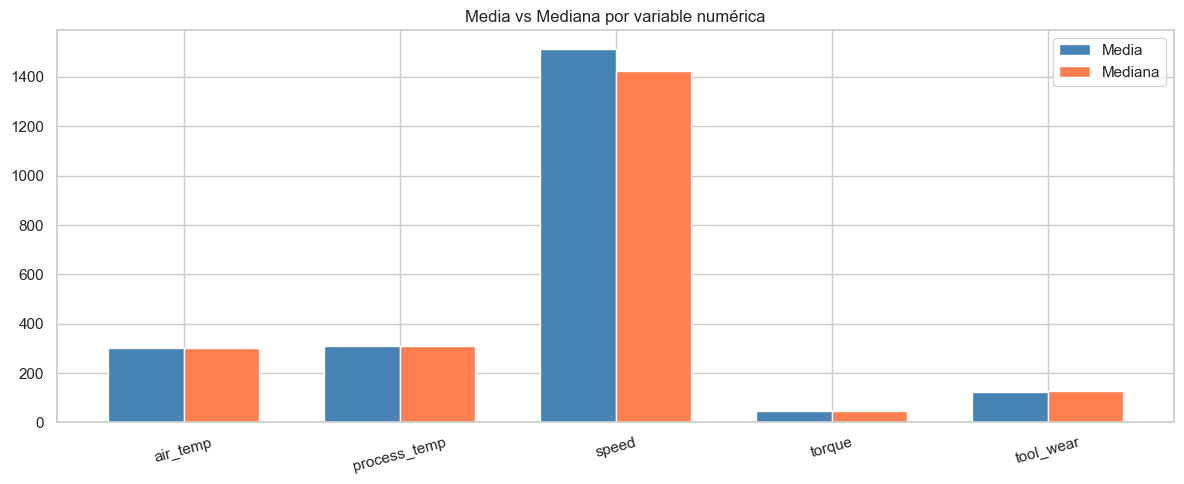

In [11]:
# Visualizamos media vs mediana en un gráfico de barras
# Si media ≈ mediana → distribución simétrica
# Si difieren mucho → distribución sesgada o con outliers

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cols_num))
width = 0.35

bars1 = ax.bar(x - width/2, tendencia_central['Media'],   width, label='Media',   color='steelblue')
bars2 = ax.bar(x + width/2, tendencia_central['Mediana'], width, label='Mediana', color='coral')

ax.set_xticks(x)
ax.set_xticklabels([c.split(' [')[0] for c in cols_num], rotation=15)
ax.set_title('Media vs Mediana por variable numérica')
ax.legend()
plt.tight_layout()
plt.show()

## 1.3 Medidas de Dispersión

Las medidas de dispersión describen cuán **esparcidos** están los datos:
- **Varianza:** promedio de las desviaciones al cuadrado respecto a la media.
- **Desviación estándar (std):** raíz cuadrada de la varianza. Misma unidad que los datos.
- **Rango:** diferencia entre máximo y mínimo.
- **IQR (Rango Intercuartílico):** diferencia entre Q3 y Q1. Robusto ante outliers.
- **CV (Coeficiente de Variación):** dispersión relativa a la media (en %).

In [54]:
Q1 = df[cols_num].quantile(0.25)
Q3 = df[cols_num].quantile(0.75)

dispersion = pd.DataFrame({
    'Varianza':  df[cols_num].var().round(3),
    'Std':       df[cols_num].std().round(3),
    'Rango':     (df[cols_num].max() - df[cols_num].min()).round(3),
    'IQR':       (Q3 - Q1).round(3),
    'CV (%)':    (df[cols_num].std() / df[cols_num].mean() * 100).round(2)
})
print('=== MEDIDAS DE DISPERSIÓN ===')
dispersion

=== MEDIDAS DE DISPERSIÓN ===


,Varianza,Std,Rango,IQR,CV (%)
air_temp [K],3.813,1.953,9.2,3.30,0.65
process_temp [K],1.768,1.330,8.1,1.89,0.43
speed [RPM],98347.575,313.604,2887.0,207.00,20.72
torque [Nm],202.397,14.227,72.8,19.01,31.65
tool_wear [min],4914.850,70.106,253.0,129.00,56.12


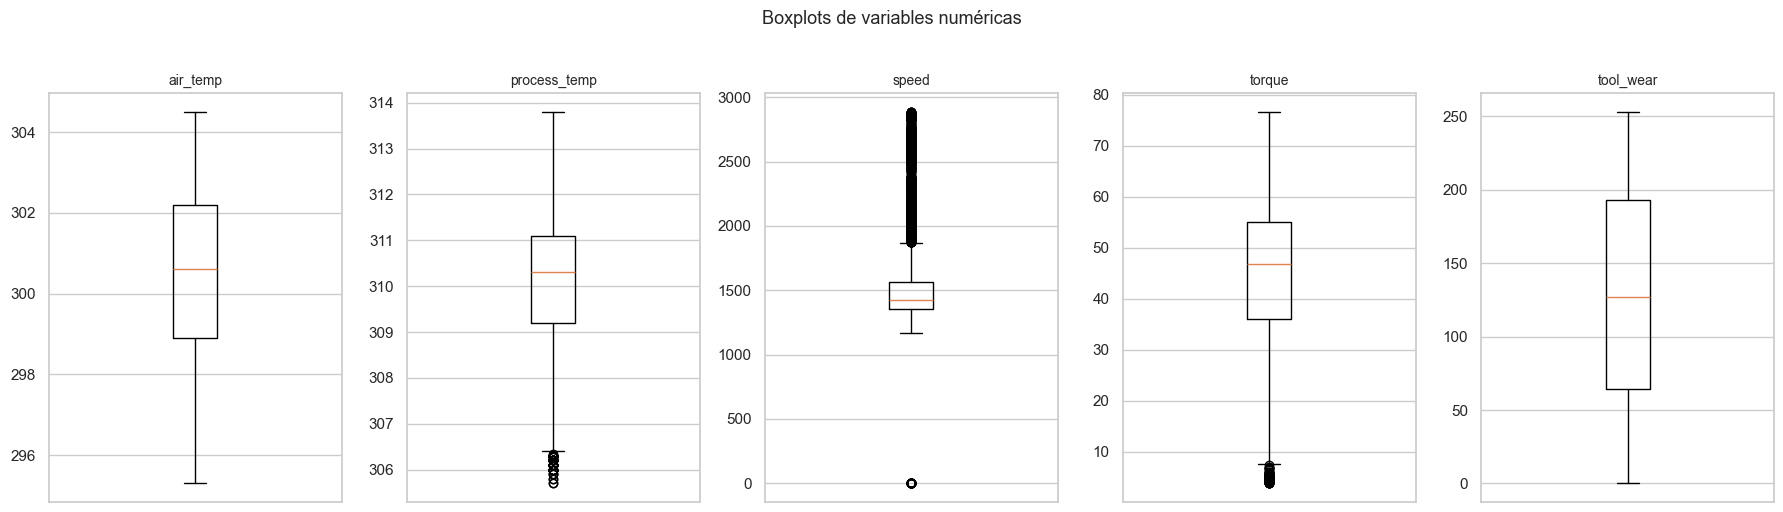

In [55]:
# Boxplots: muestran Q1, mediana, Q3, bigotes e outliers en un solo gráfico
# Son perfectos para comparar dispersión entre variables

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(cols_num):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col.split(' [')[0], fontsize=10)
    axes[i].set_xticks([])
plt.suptitle('Boxplots de variables numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 1.4 Distribuciones

Los histogramas muestran cómo se distribuyen los valores de cada variable.
Nos permiten detectar si la distribución es normal, sesgada, bimodal, etc.

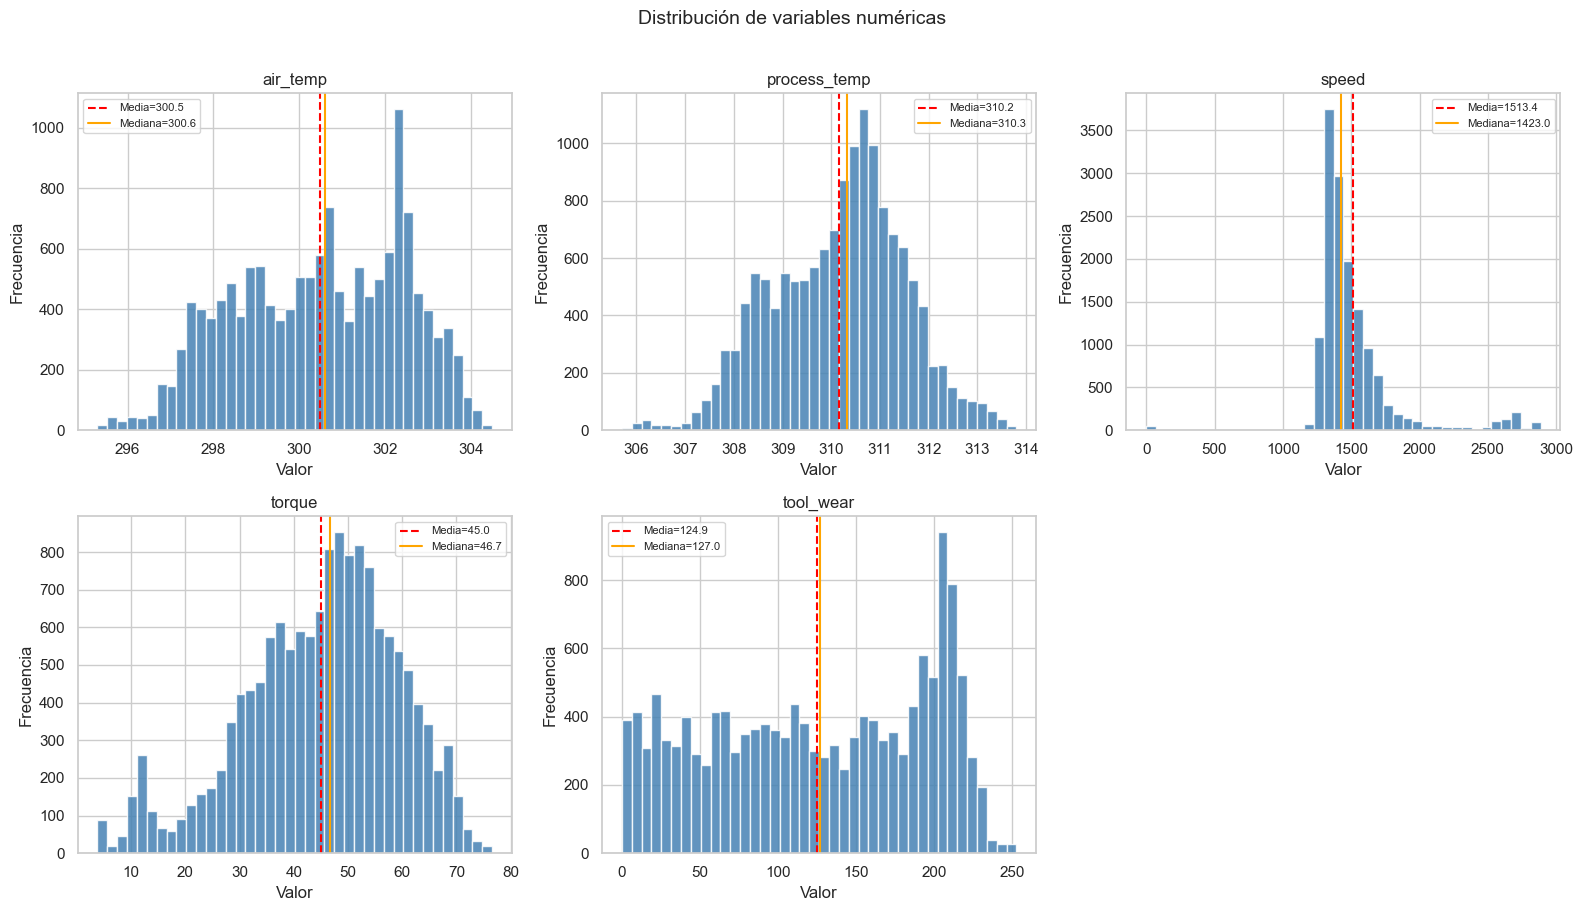

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    media   = df[col].mean()
    mediana = df[col].median()
    axes[i].axvline(media,   color='red',    linestyle='--', linewidth=1.5, label=f'Media={media:.1f}')
    axes[i].axvline(mediana, color='orange', linestyle='-',  linewidth=1.5, label=f'Mediana={mediana:.1f}')
    axes[i].set_title(col.split(' [')[0])
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

axes[-1].axis('off')  # ocultar el último subplot vacío
plt.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.5 Proporciones — Variables Categóricas

Analizamos las variables de tipo texto/categoría: `product_type` y `target`.

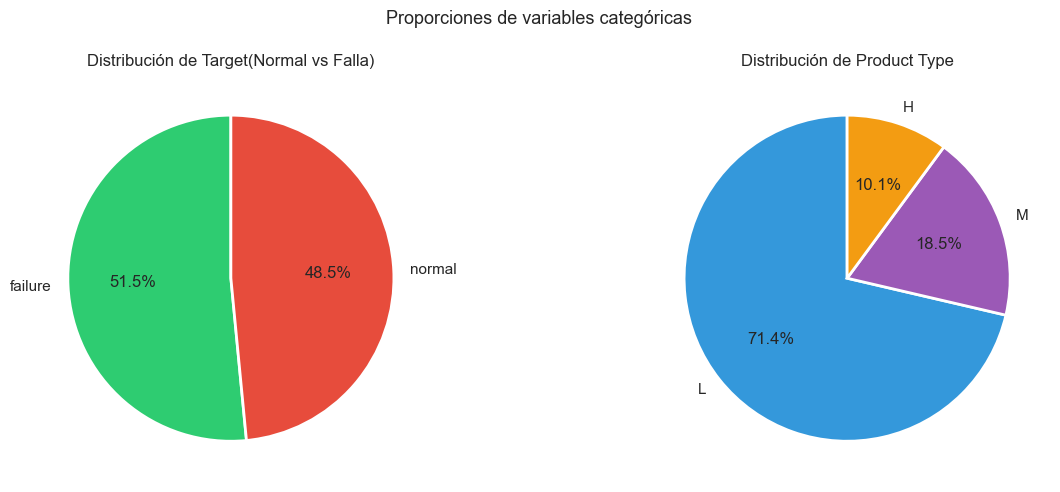

Conteo exacto:
Target: target
failure    7482
normal     7039
Product Type: product_type
L    10362
M     2691
H     1468


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- TARGET (variable a predecir) ---
conteo_target = df['target'].value_counts()
colores_target = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(
    conteo_target,
    labels=conteo_target.index,
    autopct='%1.1f%%',
    colors=colores_target,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribución de Target(Normal vs Falla)', fontsize=12)
for at in autotexts:
    at.set_fontsize(12)

# --- PRODUCT TYPE ---
conteo_pt = df['product_type'].value_counts()
colores_pt = ['#3498db', '#9b59b6', '#f39c12']
torta = axes[1].pie(
    conteo_pt,
    labels=conteo_pt.index,
    autopct='%1.1f%%',
    colors=colores_pt,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Distribución de Product Type', fontsize=12)
for at in torta[2]:
    at.set_fontsize(12)

plt.suptitle('Proporciones de variables categóricas', fontsize=13)
plt.tight_layout()
plt.show()

print('Conteo exacto:')
print('Target:', conteo_target.to_string())
print('Product Type:', conteo_pt.to_string())

=== Tasa de falla por tipo de producto (%) ===
target        failure  normal
product_type                 
H               49.93   50.07
L               59.83   40.17
M               20.40   79.60


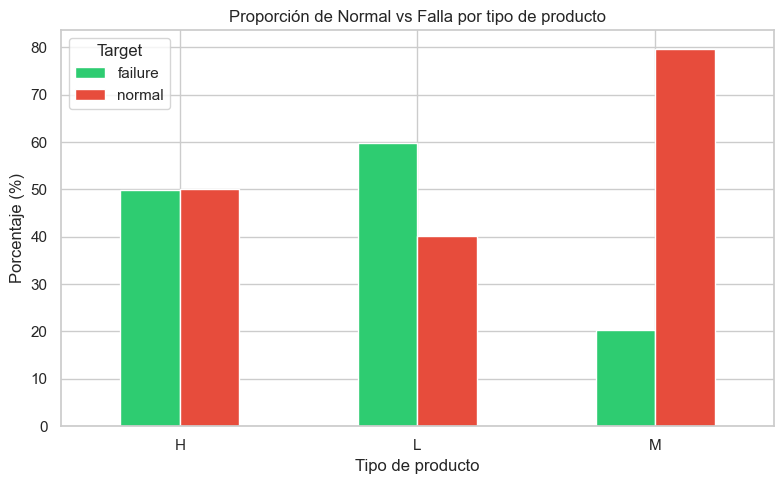

In [60]:
# Proporción de fallas por tipo de producto
# Nos dice si algún tipo de producto es más propenso a fallar
tabla_cruzada = pd.crosstab(df['product_type'], df['target'], normalize='index') * 100
print('=== Tasa de falla por tipo de producto (%) ===')
print(tabla_cruzada.round(2))

tabla_cruzada.plot(kind='bar', figsize=(8, 5), color=['#2ecc71', '#e74c3c'], edgecolor='white')
plt.title('Proporción de Normal vs Falla por tipo de producto')
plt.xlabel('Tipo de producto')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.legend(title='Target')
plt.tight_layout()
plt.show()

## 1.6 Relaciones entre Variables

Analizamos cómo se relacionan las variables entre sí y con el target.

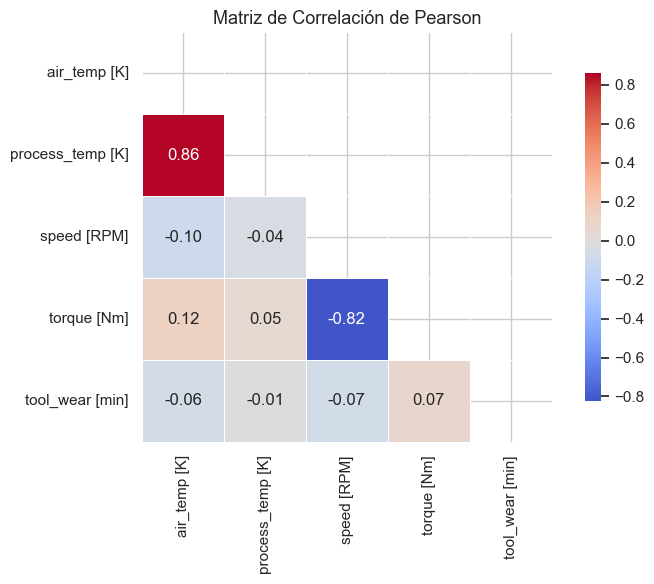

In [61]:
# Matriz de correlación de Pearson
# Valores entre -1 y 1:
#   1   → correlación positiva perfecta
#   0   → sin correlación lineal
#  -1   → correlación negativa perfecta

corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # ocultar triángulo superior (redundante)
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, mask=mask, ax=ax,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlación de Pearson', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_17692\504792267.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos, patch_artist=True,
C:\Users\franc\AppData\Local\Temp\ipykernel_17692\504792267.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos, patch_artist=True,
C:\Users\franc\AppData\Local\Temp\ipykernel_17692\504792267.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos, patch_artist=True,
C:\Users\franc\AppData\Local\Temp\ipykernel_17692\504792267.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rena

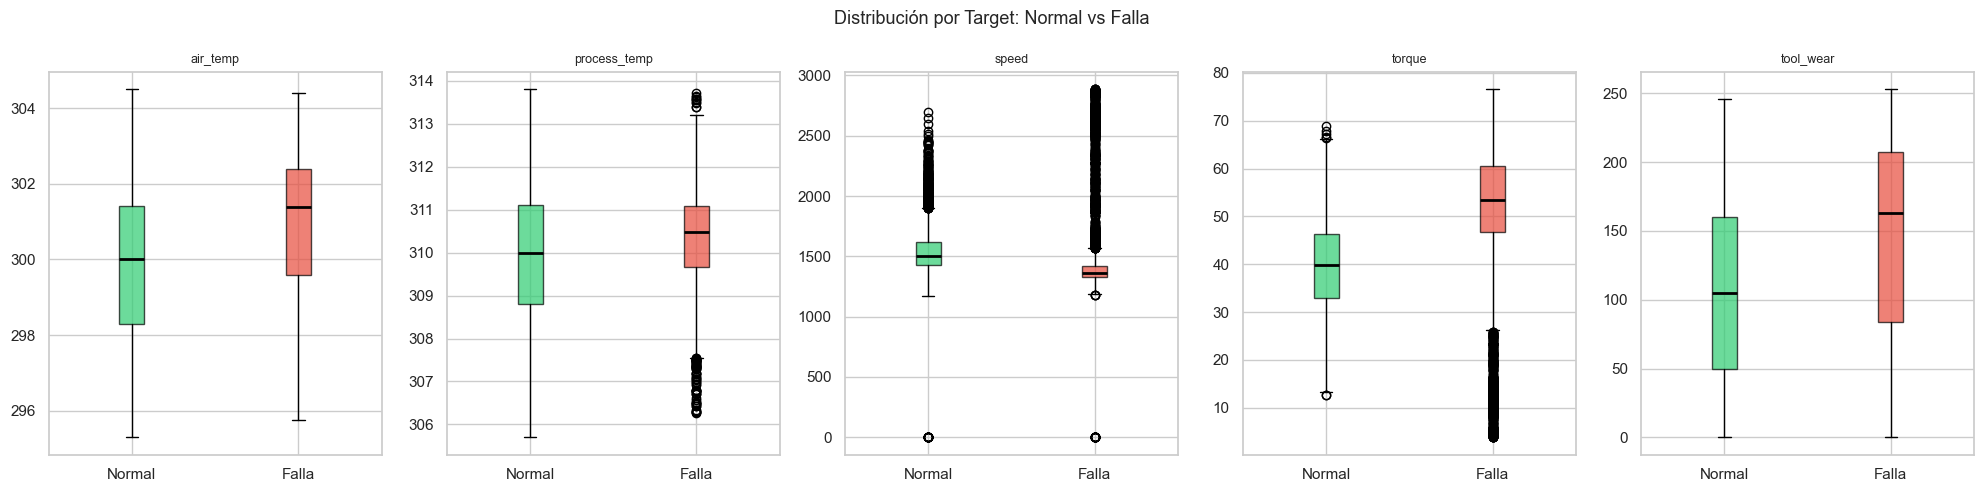

In [62]:
# Boxplots de variables numéricas separadas por target
# Nos permite ver si hay diferencias en los valores entre equipos con falla y sin falla

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
paleta = {'normal': '#2ecc71', 'failure': '#e74c3c'}

for i, col in enumerate(cols_num):
    grupos = [df[df['target'] == t][col].dropna() for t in ['normal', 'failure']]
    bp = axes[i].boxplot(grupos, patch_artist=True,
                          labels=['Normal', 'Falla'],
                          medianprops={'color': 'black', 'linewidth': 2})
    colores = ['#2ecc71', '#e74c3c']
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col.split(' [')[0], fontsize=9)

plt.suptitle('Distribución por Target: Normal vs Falla', fontsize=13)
plt.tight_layout()
plt.show()

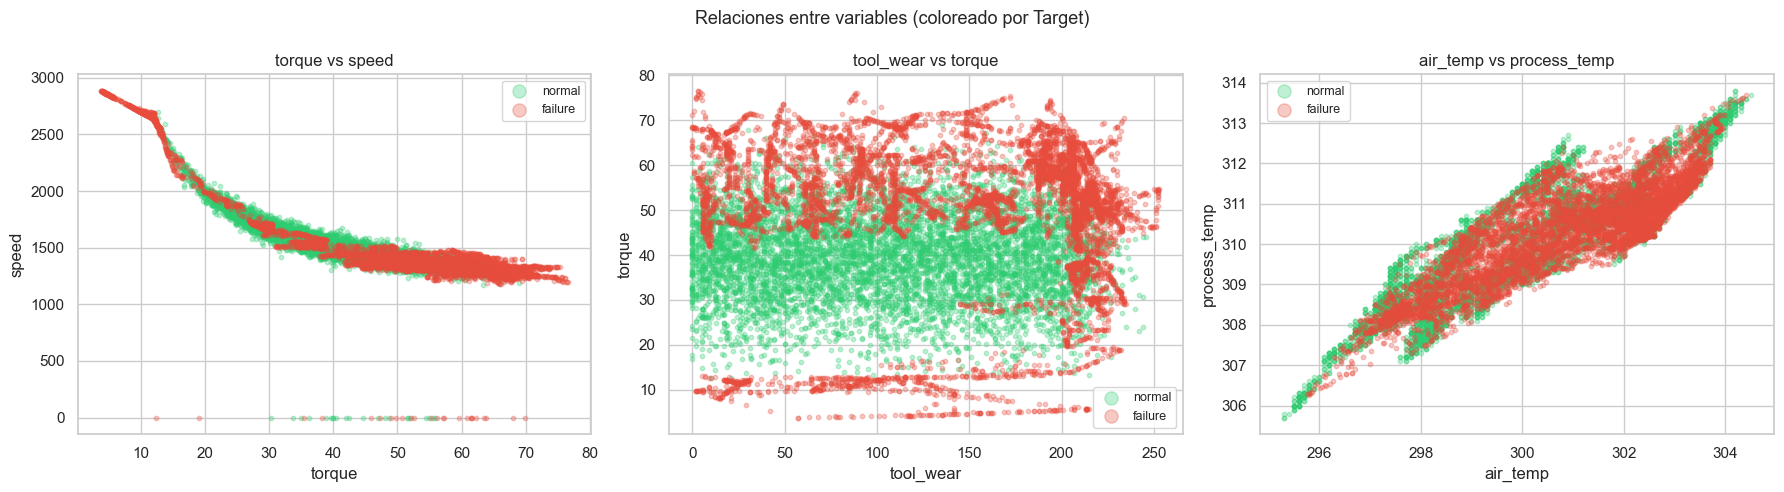

         idx  parent_device_id product_type  air_temp [K]  process_temp [K]  \
0          0              5291            L        303.80            313.30   
1          1              3908            L        302.30            311.20   
2          2             10767            M        302.27            311.47   
3          3             15484            L        302.35            311.93   
4          4               784            L        296.70            307.90   
...      ...               ...          ...           ...               ...   
14516  14516             11314            H        296.79            307.90   
14517  14517             17903            L        302.90            311.21   
14518  14518             18156            M        302.53            311.91   
14519  14519             15435            L        300.11            309.98   
14520  14520               815            M        296.80            307.50   

       speed [RPM]  torque [Nm]  tool_wear [min]   

In [ ]:
# Scatter plots: relación entre pares de variables, coloreadas por target
# Nos permite ver si las clases son separables visualmente

pares = [
    ('torque [Nm]',     'speed [RPM]'),
    ('tool_wear [min]', 'torque [Nm]'),
    ('air_temp [K]',    'process_temp [K]')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores_map = {'normal': '#2ecc71', 'failure': '#e74c3c'}



for ax, (xcol, ycol) in zip(axes, pares):
    for clase, color in colores_map.items():
        subset = df[df['target'] == clase]
        ax.scatter(subset[xcol], subset[ycol],
                   c=color, label=clase, alpha=0.3, s=10)
    ax.set_xlabel(xcol.split(' [')[0])
    ax.set_ylabel(ycol.split(' [')[0])
    ax.set_title(f'{xcol.split(" [")[0]} vs {ycol.split(" [")[0]}')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle('Relaciones entre variables (coloreado por Target)', fontsize=13)
plt.tight_layout()
plt.show()


---
# PARTE 2 — Preprocesamiento y Modelos de Machine Learning

En esta parte preparamos los datos para los algoritmos de ML y entrenamos varios modelos.

## 2.1 Análisis y Limpieza de Variables

In [ ]:
# Trabajamos sobre una copia para no modificar el DataFrame original
df_proc = df.copy()

# Las columnas 'idx' y 'parent_device_id' son solo identificadores
# No aportan información predictiva → las eliminamos
df_proc.drop(columns=['idx', 'parent_device_id'], inplace=True)
print('Columnas después de eliminar identificadores:')
print(df_proc.columns.tolist())

In [ ]:
# ── Valores nulos / faltantes ──
# Si hay nulos, debemos decidir: eliminar filas, rellenar con media/mediana/moda, etc.
nulos = df_proc.isnull().sum()
print('Valores nulos por columna:')
print(nulos)
print(f'\nTotal de nulos: {nulos.sum()}')

In [ ]:
# ── Valores duplicados ──
n_dup = df_proc.duplicated().sum()
print(f'Filas duplicadas: {n_dup}')
if n_dup > 0:
    df_proc.drop_duplicates(inplace=True)
    print(f'Duplicados eliminados. Filas restantes: {len(df_proc)}')

## 2.2 Detección y Tratamiento de Valores Atípicos (Outliers)

Un **outlier** es un valor muy alejado del resto. Pueden ser errores de medición o valores reales extremos.

Método **IQR**: se considera outlier a todo valor que esté:
- Por debajo de `Q1 - 1.5 × IQR`
- Por encima de `Q3 + 1.5 × IQR`

In [ ]:
print('=== DETECCIÓN DE OUTLIERS (Método IQR) ===')
resumen_outliers = []

for col in cols_num:
    Q1  = df_proc[col].quantile(0.25)
    Q3  = df_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out   = ((df_proc[col] < lim_inf) | (df_proc[col] > lim_sup)).sum()
    resumen_outliers.append({
        'Variable': col.split(' [')[0],
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Límite inf.': round(lim_inf, 2), 'Límite sup.': round(lim_sup, 2),
        'Outliers': n_out, 'Outliers (%)': round(n_out / len(df_proc) * 100, 2)
    })

pd.DataFrame(resumen_outliers).set_index('Variable')

In [ ]:
# Estrategia: recorte (capping) de outliers al límite del IQR
# En lugar de eliminar filas, limitamos los valores extremos
# Esto preserva más datos y es útil en datasets industriales donde los extremos pueden ser reales

for col in cols_num:
    Q1  = df_proc[col].quantile(0.25)
    Q3  = df_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    df_proc[col] = df_proc[col].clip(lower=lim_inf, upper=lim_sup)

print('Outliers recortados con capping IQR.')
print('Nuevos valores extremos:')
df_proc[cols_num].agg(['min', 'max']).round(2)

## 2.3 Procesamiento de Variables Categóricas

Los modelos de ML trabajan con números, no con texto.
- `product_type` (L, M, H): aplicamos **Label Encoding** (L→0, M→1, H→2).
- `target` (normal, failure): codificamos como 0 y 1.

In [ ]:
# Label Encoding para product_type
le_product = LabelEncoder()
df_proc['product_type'] = le_product.fit_transform(df_proc['product_type'])
print('Clases product_type:', le_product.classes_, '→ Valores:', list(range(len(le_product.classes_))))

# Codificación de target: failure=1, normal=0
df_proc['target'] = (df_proc['target'] == 'failure').astype(int)

print('\nDistribución de target codificado:')
print(df_proc['target'].value_counts())
df_proc.head()

## 2.4 Balance del Conjunto de Datos

Un dataset desbalanceado (ej: 95% normal, 5% falla) puede hacer que el modelo ignore la clase minoritaria.

Verificamos el balance y, si es necesario, aplicamos **oversampling** de la clase minoritaria.

In [ ]:
conteo = df_proc['target'].value_counts()
ratio  = conteo.min() / conteo.max()
print(f'Clase 0 (normal):  {conteo[0]:,}')
print(f'Clase 1 (failure): {conteo[1]:,}')
print(f'Ratio minoritaria/mayoritaria: {ratio:.3f}')

if ratio >= 0.8:
    print('\nEl dataset está suficientemente balanceado (ratio ≥ 0.8). No se aplica balanceo.')
else:
    print(f'\nDataset desbalanceado (ratio = {ratio:.2f}). Aplicando oversampling...')
    mayoria  = df_proc[df_proc['target'] == conteo.idxmax()]
    minoria  = df_proc[df_proc['target'] == conteo.idxmin()]
    minoria_up = resample(minoria, replace=True, n_samples=len(mayoria), random_state=42)
    df_proc = pd.concat([mayoria, minoria_up]).sample(frac=1, random_state=42).reset_index(drop=True)
    print('Nuevo balance:')
    print(df_proc['target'].value_counts())

## 2.5 Separación de Features y Target — Train/Test Split

Dividimos el dataset en:
- **X**: variables de entrada (features)
- **y**: variable de salida (lo que queremos predecir)

Luego separamos en **entrenamiento (80%)** y **prueba (20%)**.
`stratify=y` asegura que ambas particiones tengan la misma proporción de clases.

In [ ]:
X = df_proc.drop(columns=['target'])
y = df_proc['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]:,} filas')
print(f'Conjunto de prueba:        {X_test.shape[0]:,} filas')
print(f'Features: {list(X.columns)}')

## 2.6 Normalización

Muchos modelos (Regresión Logística, KNN) son sensibles a la escala de las variables.
**StandardScaler** transforma cada variable para que tenga **media = 0** y **std = 1**.

> **Importante:** ajustamos el scaler SOLO sobre los datos de entrenamiento (`fit_transform`),
> y luego lo aplicamos sobre los de prueba (`transform`). Así evitamos **data leakage**.

In [ ]:
scaler = StandardScaler()

# fit_transform: calcula media/std del train y transforma
X_train_sc = scaler.fit_transform(X_train)
# transform: usa la media/std del train para transformar el test
X_test_sc  = scaler.transform(X_test)

# Convertimos a DataFrame para mantener los nombres de columnas
X_train_sc = pd.DataFrame(X_train_sc, columns=X.columns)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=X.columns)

print('Estadísticas del train escalado (media ≈ 0, std ≈ 1):')
X_train_sc.describe().round(3)

## 2.7 Función de Evaluación de Modelos

Creamos una función reutilizable que calcule todas las métricas importantes y grafique la matriz de confusión.

In [ ]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, resultados):
    """
    Entrena el modelo, calcula métricas y grafica la matriz de confusión.
    Retorna el diccionario de resultados actualizado.
    """
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    print(f'\n{'='*55}')
    print(f'  MODELO: {nombre}')
    print(f'{'='*55}')
    print(f'  Accuracy:  {acc:.4f}  → % de predicciones correctas')
    print(f'  Precision: {prec:.4f}  → de los que predije como falla, cuántos eran falla')
    print(f'  Recall:    {rec:.4f}  → de todos los que eran falla, cuántos detecté')
    print(f'  F1-Score:  {f1:.4f}  → media armónica entre Precision y Recall')
    if auc:
        print(f'  ROC-AUC:   {auc:.4f}  → capacidad de discriminar entre clases')
    print()
    print(classification_report(y_te, y_pred, target_names=['Normal', 'Falla']))

    # Matriz de confusión
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Falla'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión — {nombre}')
    plt.tight_layout()
    plt.show()

    resultados[nombre] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC-AUC': auc
    }
    return resultados

resultados = {}
print('Función de evaluación definida.')

## 2.8 Modelo 1: Regresión Logística

La **Regresión Logística** es un modelo lineal para clasificación.
Calcula la probabilidad de pertenecer a una clase usando la función sigmoide.
Es simple, interpretable y un buen punto de partida (baseline).

In [ ]:
# Usamos los datos escalados ya que la Regresión Logística es sensible a la escala
print('Entrenando Regresión Logística...')
rl = LogisticRegression(max_iter=1000, random_state=42)
resultados = evaluar_modelo('Reg. Logística', rl, X_train_sc, y_train, X_test_sc, y_test, resultados)

In [ ]:
# Búsqueda de hiperparámetros para Regresión Logística
# C: inverso de la regularización (mayor C = menos regularización)
# penalty: tipo de regularización (l2 es la más común)
print('Buscando mejores hiperparámetros para Regresión Logística...')

param_grid_rl = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver':  ['lbfgs']
}

grid_rl = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_rl,
    cv=5,           # validación cruzada de 5 pliegues
    scoring='f1',   # optimizamos F1
    n_jobs=-1       # usa todos los núcleos disponibles
)
grid_rl.fit(X_train_sc, y_train)

print(f'Mejores parámetros: {grid_rl.best_params_}')
print(f'Mejor F1 en CV:     {grid_rl.best_score_:.4f}')

resultados = evaluar_modelo(
    'Reg. Logística (tuned)', grid_rl.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test, resultados
)

## 2.9 Modelo 2: Árbol de Decisión

Un **Árbol de Decisión** divide el espacio de features haciendo preguntas del tipo "¿es X > umbral?".
Es muy interpretable (se puede visualizar) pero tiende al **overfitting** si no se controla su profundidad.

In [ ]:
# El árbol de decisión no requiere escalado
print('Entrenando Árbol de Decisión (sin escalar)...')
dt = DecisionTreeClassifier(random_state=42)
resultados = evaluar_modelo('Árbol de Decisión', dt, X_train, y_train, X_test, y_test, resultados)

In [ ]:
# Búsqueda de hiperparámetros para el Árbol de Decisión
# max_depth: profundidad máxima del árbol
# min_samples_split: mínimo de muestras para dividir un nodo
# criterion: criterio de impureza (gini o entropy)
print('Buscando mejores hiperparámetros para Árbol de Decisión...')

param_grid_dt = {
    'max_depth':        [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'criterion':        ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=5, scoring='f1', n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(f'Mejores parámetros: {grid_dt.best_params_}')
print(f'Mejor F1 en CV:     {grid_dt.best_score_:.4f}')

resultados = evaluar_modelo(
    'Árbol de Decisión (tuned)', grid_dt.best_estimator_,
    X_train, y_train, X_test, y_test, resultados
)

In [ ]:
# Visualización del árbol (limitamos la profundidad para que sea legible)
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    grid_dt.best_estimator_,
    max_depth=3,                  # solo mostramos los primeros 3 niveles
    feature_names=X.columns,
    class_names=['Normal', 'Falla'],
    filled=True, rounded=True,
    ax=ax, fontsize=9
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=13)
plt.tight_layout()
plt.show()

## 2.10 Modelo 3: K-Nearest Neighbors (KNN)

**KNN** clasifica un punto según los `k` vecinos más cercanos en el espacio de features.
Es simple y no paramétrico, pero sensible a la escala → siempre usar datos normalizados.

In [ ]:
print('Entrenando KNN...')
knn = KNeighborsClassifier()
resultados = evaluar_modelo('KNN', knn, X_train_sc, y_train, X_test_sc, y_test, resultados)

In [ ]:
# Buscamos el mejor k (número de vecinos)
print('Buscando mejor k para KNN...')

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'metric':      ['euclidean', 'manhattan'],
    'weights':     ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, cv=5, scoring='f1', n_jobs=-1
)
grid_knn.fit(X_train_sc, y_train)

print(f'Mejores parámetros: {grid_knn.best_params_}')
print(f'Mejor F1 en CV:     {grid_knn.best_score_:.4f}')

resultados = evaluar_modelo(
    'KNN (tuned)', grid_knn.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test, resultados
)

## 2.11 Modelo Ensamblado: Random Forest

**Random Forest** entrena múltiples árboles de decisión en paralelo, cada uno sobre una muestra aleatoria del dataset y un subconjunto aleatorio de features.
La predicción final es por **votación mayoritaria**.

Ventajas:
- Muy robusto ante overfitting
- No necesita escalado
- Permite calcular la importancia de cada feature

In [ ]:
print('Entrenando Random Forest...')
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
resultados = evaluar_modelo('Random Forest', rf, X_train, y_train, X_test, y_test, resultados)

In [ ]:
# Búsqueda de hiperparámetros para Random Forest
# n_estimators: cantidad de árboles
# max_depth: profundidad máxima de cada árbol
# max_features: número de features a considerar en cada split
print('Buscando mejores hiperparámetros para Random Forest...')

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20, None],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f'Mejores parámetros: {grid_rf.best_params_}')
print(f'Mejor F1 en CV:     {grid_rf.best_score_:.4f}')

resultados = evaluar_modelo(
    'Random Forest (tuned)', grid_rf.best_estimator_,
    X_train, y_train, X_test, y_test, resultados
)

In [ ]:
# Importancia de features del Random Forest
# Nos dice qué variables contribuyeron más a las predicciones
importancias = pd.Series(
    grid_rf.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importancias.index, importancias.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importancia relativa')
ax.set_title('Importancia de Features — Random Forest')
plt.tight_layout()
plt.show()

## 2.12 Comparativa Final de Modelos

In [ ]:
# Tabla comparativa de todas las métricas
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.astype(float).round(4)

# Resaltamos el mejor valor de cada columna
print('=== COMPARATIVA DE MODELOS ===')
df_resultados.style.highlight_max(color='#aaffaa', axis=0)

In [ ]:
# Gráfico comparativo de barras agrupadas
metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
df_plot  = df_resultados[metricas].dropna(how='all')

fig, ax = plt.subplots(figsize=(15, 6))
x     = np.arange(len(df_plot))
width = 0.15
colores = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for i, metrica in enumerate(metricas):
    valores = df_plot[metrica].values
    bars = ax.bar(x + i*width, valores, width, label=metrica,
                  color=colores[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * (len(metricas)-1) / 2)
ax.set_xticklabels(df_plot.index, rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparativa de Modelos — Todas las Métricas', fontsize=13)
ax.legend(loc='lower right')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4, label='0.9 ref')
plt.tight_layout()
plt.show()

In [ ]:
# Curvas ROC superpuestas para comparar modelos que soportan predict_proba
modelos_roc = {
    'Reg. Logística': (grid_rl.best_estimator_, X_test_sc),
    'Árbol de Decisión': (grid_dt.best_estimator_, X_test),
    'KNN':            (grid_knn.best_estimator_, X_test_sc),
    'Random Forest':  (grid_rf.best_estimator_, X_test),
}

fig, ax = plt.subplots(figsize=(8, 6))
colores_roc = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for (nombre, (modelo, X_eval)), color in zip(modelos_roc.items(), colores_roc):
    y_prob = modelo.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{nombre} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curvas ROC — Comparativa de Modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Resumen final: mejor modelo según F1-Score
mejor = df_resultados['F1'].idxmax()
print(f'Mejor modelo según F1-Score: {mejor}')
print(f'\nMétricas:')
print(df_resultados.loc[mejor].to_string())